# 1.환경 준비

In [1]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'

In [2]:
# 데이터 불러오기
path = 'data/attrition.csv'
df = pd.read_csv(path)

# 2.데이터 이해

In [3]:
# 데이터 살펴보기
df.head()

,Attrition,Age,DistanceFromHome,EmployeeNumber,Gender,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,TotalWorkingYears
0,0,33,7,817,Male,3,Married,11691,No,11,14
1,0,35,18,1412,Male,4,Single,9362,No,11,10
2,0,42,6,1911,Male,1,Married,13348,No,13,18
3,0,46,2,1204,Female,1,Married,17048,No,23,28
4,1,22,4,593,Male,3,Single,3894,No,16,4


**데이터 설명**

- Attrition: 이직 여부 (1: 이직, 0: 잔류)
- Age: 나이
- DistanceFromHome: 집-직장 거리 (단위: 마일)
- EmployeeNumber: 사번
- Gender: 성별 (Male, Female)
- JobSatisfaction: 직무 만족도(1: Low, 2: Medium, 3: High, 4: Very High)
- MaritalStatus: 결혼 상태 (Single, Married, Divorced)
- MonthlyIncome: 월급 (단위: 달러)
- OverTime: 야근 여부 (Yes, No)
- PercentSalaryHike: 전년 대비 급여 인상율(단위: %)
- TotalWorkingYears: 총 경력 연수

In [4]:
# 기술통계 확인
df.describe()

,Attrition,Age,DistanceFromHome,EmployeeNumber,JobSatisfaction,MonthlyIncome,PercentSalaryHike,TotalWorkingYears
count,1196.000000,1196.00000,1196.000000,1196.000000,1196.000000,1196.000000,1196.000000,1196.000000
mean,0.163043,36.94398,9.258361,1035.629599,2.716555,6520.104515,15.251672,11.330268
std,0.369560,9.09270,8.166016,604.340130,1.110962,4665.902253,3.625946,7.823821
min,0.000000,18.00000,1.000000,1.000000,1.000000,1009.000000,11.000000,0.000000
25%,0.000000,30.00000,2.000000,507.750000,2.000000,2928.250000,12.000000,6.000000
50%,0.000000,36.00000,7.000000,1028.000000,3.000000,4973.500000,14.000000,10.000000
75%,0.000000,43.00000,14.000000,1581.250000,4.000000,8420.500000,18.000000,15.000000
max,1.000000,60.00000,29.000000,2068.000000,4.000000,19999.000000,25.000000,40.000000


# 3.데이터 전처리

**1) 변수 제거**

- 제거 대상 변수: EmployeeNumber

In [49]:
# 제거 대상: EmployeeNumber
drop_cols = ['EmployeeNumber']

# 변수 제거
df.drop(drop_cols, axis=1, inplace=True)

# 확인
df.head()

,Attrition,Age,DistanceFromHome,Gender,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,TotalWorkingYears
0,0,33,7,Male,3,Married,11691,No,11,14
1,0,35,18,Male,4,Single,9362,No,11,10
2,0,42,6,Male,1,Married,13348,No,13,18
3,0,46,2,Female,1,Married,17048,No,23,28
4,1,22,4,Male,3,Single,3894,No,16,4


**2) x, y 분리**

In [50]:
# target 확인
target = 'Attrition'

# 데이터 분리
X = df.drop(target, axis=1)
y = df[target]


**3) 가변수화**

In [51]:
# 가변수화 대상: Gender, JobSatisfaction, MaritalStatus, OverTime
df_dummies = ['Gender', 'JobSatisfaction', 'MaritalStatus', 'OverTime']

# 가변수화
X = pd.get_dummies(X, columns=df_dummies, drop_first=True)

# 확인
X.head()

,Age,DistanceFromHome,MonthlyIncome,PercentSalaryHike,TotalWorkingYears,Gender_Male,JobSatisfaction_2,JobSatisfaction_3,JobSatisfaction_4,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,33,7,11691,11,14,True,False,True,False,True,False,False
1,35,18,9362,11,10,True,False,False,True,False,True,False
2,42,6,13348,13,18,True,False,False,False,True,False,False
3,46,2,17048,23,28,False,False,False,False,True,False,False
4,22,4,3894,16,4,True,False,True,False,False,True,False


**4) 학습용, 평가용 데이터 분리**

In [52]:
# 모듈 불러오기
from sklearn.model_selection import train_test_split

# 데이터 분리
X_train,X_test, y_train, y_test = train_test_split(X, y,
                                                   train_size=0.7,
                                                   random_state=3
                                                   )

**5) 정규화**

In [53]:
# 모듈 불러오기
from sklearn.preprocessing import MinMaxScaler
# 정규화
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)




# 4.성능 예측

- 여러 알고리즘으로 모델을 만들고 K-Fold CV로 성능을 예측한다.
- 하이퍼파라미터를 설정하지 않고 진행한다.
- 각 모델의 성능 정보를 수집해 마지막에 비교한다.

In [10]:
# xgboost 설치
# pip install xgboost

In [11]:
# lightgbm 설치
# pip install lightgbm

- 이후 사용할 함수를 모두 불러옵니다.

In [54]:
# 라이브러리 불러오기
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import *
from sklearn.model_selection import cross_val_score, RandomizedSearchCV


**1) KNN**

- KNN 알고리즘으로 모델링하고 K-Fold CV로 성능 검증

In [56]:
# 선언하기
model_knn = KNeighborsClassifier()

In [58]:
# 성능예측
cv_score = cross_val_score(model_knn, X_train, y_train, cv=5, scoring='accuracy')

In [59]:
# 결과확인
print(cv_score)
print('평균 :', cv_score.mean())
print('표준편차 :', cv_score.std())

[0.83928571 0.82142857 0.83233533 0.80838323 0.83233533]
평균 : 0.8267536355859709
표준편차 : 0.010818424901658713


In [60]:
# 결과수집
result = {}
result['KNN'] = cv_score.mean()


**2) Decision Tree**

- Decision Tree 알고리즘으로 모델링하고 K-Fold CV로 성능 검증

In [61]:
# 선언하기
model_dt = DecisionTreeClassifier(max_depth=5)

In [62]:
# 성능예측
cv_score = cross_val_score(model_dt, X_train, y_train, cv=5, scoring='accuracy')

In [63]:
# 결과확인
print(cv_score)
print(cv_score.mean())
print(cv_score.std())

[0.82738095 0.86309524 0.83233533 0.83233533 0.82035928]
0.8351012261191902
0.014668964762989805


In [64]:
# 결과수집
result['DT'] = cv_score.mean()

**3) Logistic Regression**

- Logistic Regression 알고리즘으로 모델링하고 K-Fold CV로 성능 검증

In [66]:
# 선언하기
model_lr = LogisticRegression()

In [67]:
# 성능예측
cv_score = cross_val_score(model_lr, X_train, y_train, cv=5, scoring='accuracy')

In [68]:
# 결과확인
print(cv_score)
print(cv_score.mean())
print(cv_score.std())

[0.85714286 0.8452381  0.84431138 0.86227545 0.84431138]
0.8506558311947534
0.007575659452236205


In [69]:
# 결과수집
result['LR'] = cv_score.mean()

**4) SVM**

- SVM 알고리즘으로 모델링하고 K-Fold CV로 성능 검증

In [71]:
# 선언하기
model_svc = SVC(kernel='linear', C=1, random_state=1)

In [72]:
# 성능예측
cv_score = cross_val_score(model_svc, X_train, y_train, cv=5, scoring='accuracy')

In [74]:
# 결과확인
print(cv_score)
print(cv_score.mean())
print(cv_score.std())

[0.83928571 0.83928571 0.83832335 0.83832335 0.84431138]
0.8399059024807528
0.0022443884939168917


In [76]:
# 결과수집
result['SVC'] = cv_score.mean()

**5) Random Forest**

- Random Forest 알고리즘으로 모델링하고 K-Fold CV로 성능 검증

In [77]:
# 선언하기
model_rf = RandomForestClassifier()

In [78]:
# 성능예측
cv_score = cross_val_score(model_rf, X_train, y_train, cv=5, scoring='accuracy')

In [79]:
# 결과확인
print(cv_score)
print(cv_score.mean())
print(cv_score.std())

[0.86309524 0.85714286 0.8502994  0.85628743 0.83832335]
0.8530296549757628
0.008397345496930343


In [80]:
# 결과수집
result['RF'] = cv_score.mean()

**6) XGBoost**

- XGBoost 알고리즘으로 모델링하고 K-Fold CV로 성능 검증

In [81]:
# 선언하기
model_XGB = XGBClassifier()

In [82]:
# 성능예측
cv_score = cross_val_score(model_XGB, X_train, y_train, cv=5, scoring='accuracy')

In [83]:
# 결과확인
print(cv_score)
print(cv_score.mean())
print(cv_score.std())

[0.83928571 0.86904762 0.82035928 0.86227545 0.80838323]
0.8398702594810381
0.0233485057063259


In [84]:
# 결과수집
result['XGB'] = cv_score.mean()

**7) LightGBM**

- LightGBM 알고리즘으로 모델링하고 K-Fold CV로 성능 검증

In [86]:
# 선언하기
model_lgbm = LGBMClassifier(min_child_samples=5,
                            max_depth=15,
                            min_split_gain=0.0,
                            colsample_bytree=1.0,
                            verbose=-1
                            )

In [87]:
# 성능예측
cv_score = cross_val_score(model_lgbm, X_train, y_train, cv=5, scoring='accuracy')

In [88]:
# 결과확인
result['LGBM'] = cv_score.mean()

In [89]:
# 결과수집
print(cv_score)
print(cv_score.mean())
print(cv_score.std())

[0.83928571 0.8452381  0.83233533 0.8502994  0.82634731]
0.8387011690903906
0.008610853019494403


# 5.결과 확인

- 예측된 각 모델의 성능 비교

In [90]:
# 성능 비교
df_result = pd.DataFrame.from_dict(result, orient='index', columns=['score'])
df_result.sort_values(by='score', ascending=True, inplace=True)

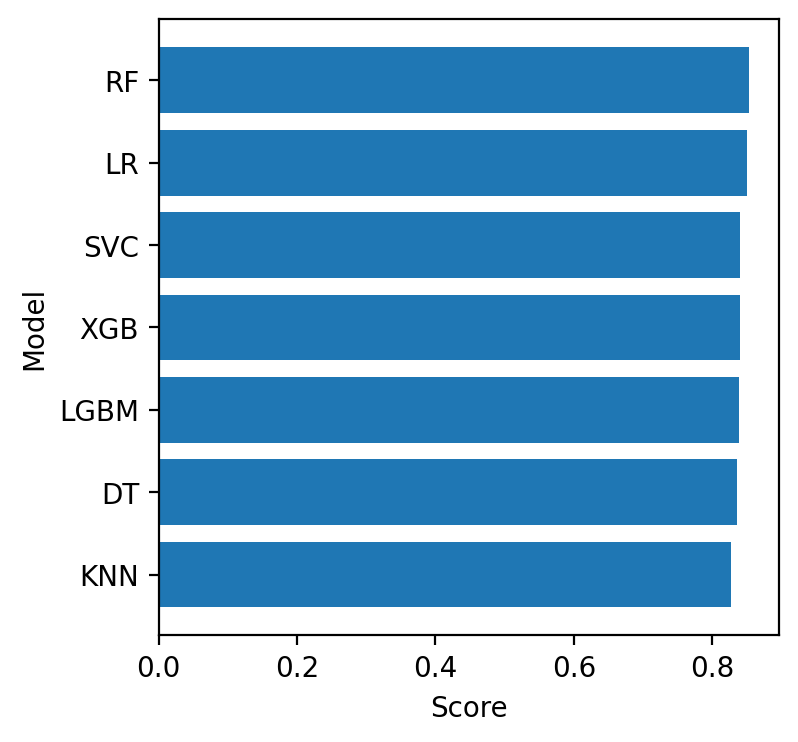

In [91]:
# 성능 시각화 비교
plt.figure(figsize=(4,4))
plt.barh(y=df_result.index, width=df_result['score'])
plt.xlabel('Score')
plt.ylabel('Model')
plt.show()

# 6.성능 튜닝

- 위에서 성능이 가장 좋을 것으로 예측된 모델 튜닝

In [92]:
# 기본 모델 선언
modelno1 = model_rf

# 파라미터 지정
param = {'max_depth' : range(1,51)}

# 모델 선언
model = RandomizedSearchCV(modelno1, param, cv=5, n_iter=20, scoring='accuracy')


In [93]:
# 학습하기(많은 시간이 소요될 수 있음)
model.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': range(1, 51)}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: 

In [94]:
# mean_test_score 확인
print(model.cv_results_['mean_test_score'])
print('-'*70)
print('최적의 파라미터 :', model.best_params_)
print('-'*70)
print('최고의 성능 :', model.best_score_)

[0.84945823 0.84944397 0.8494511  0.85780582 0.85423439 0.85182492
 0.86377958 0.85422013 0.85661534 0.85420587 0.85302253 0.85063445
 0.85184631 0.85182492 0.85185344 0.8399059  0.84704876 0.85781295
 0.8494511  0.854213  ]
----------------------------------------------------------------------
최적의 파라미터 : {'max_depth': 15}
----------------------------------------------------------------------
최고의 성능 : 0.8637795836897635


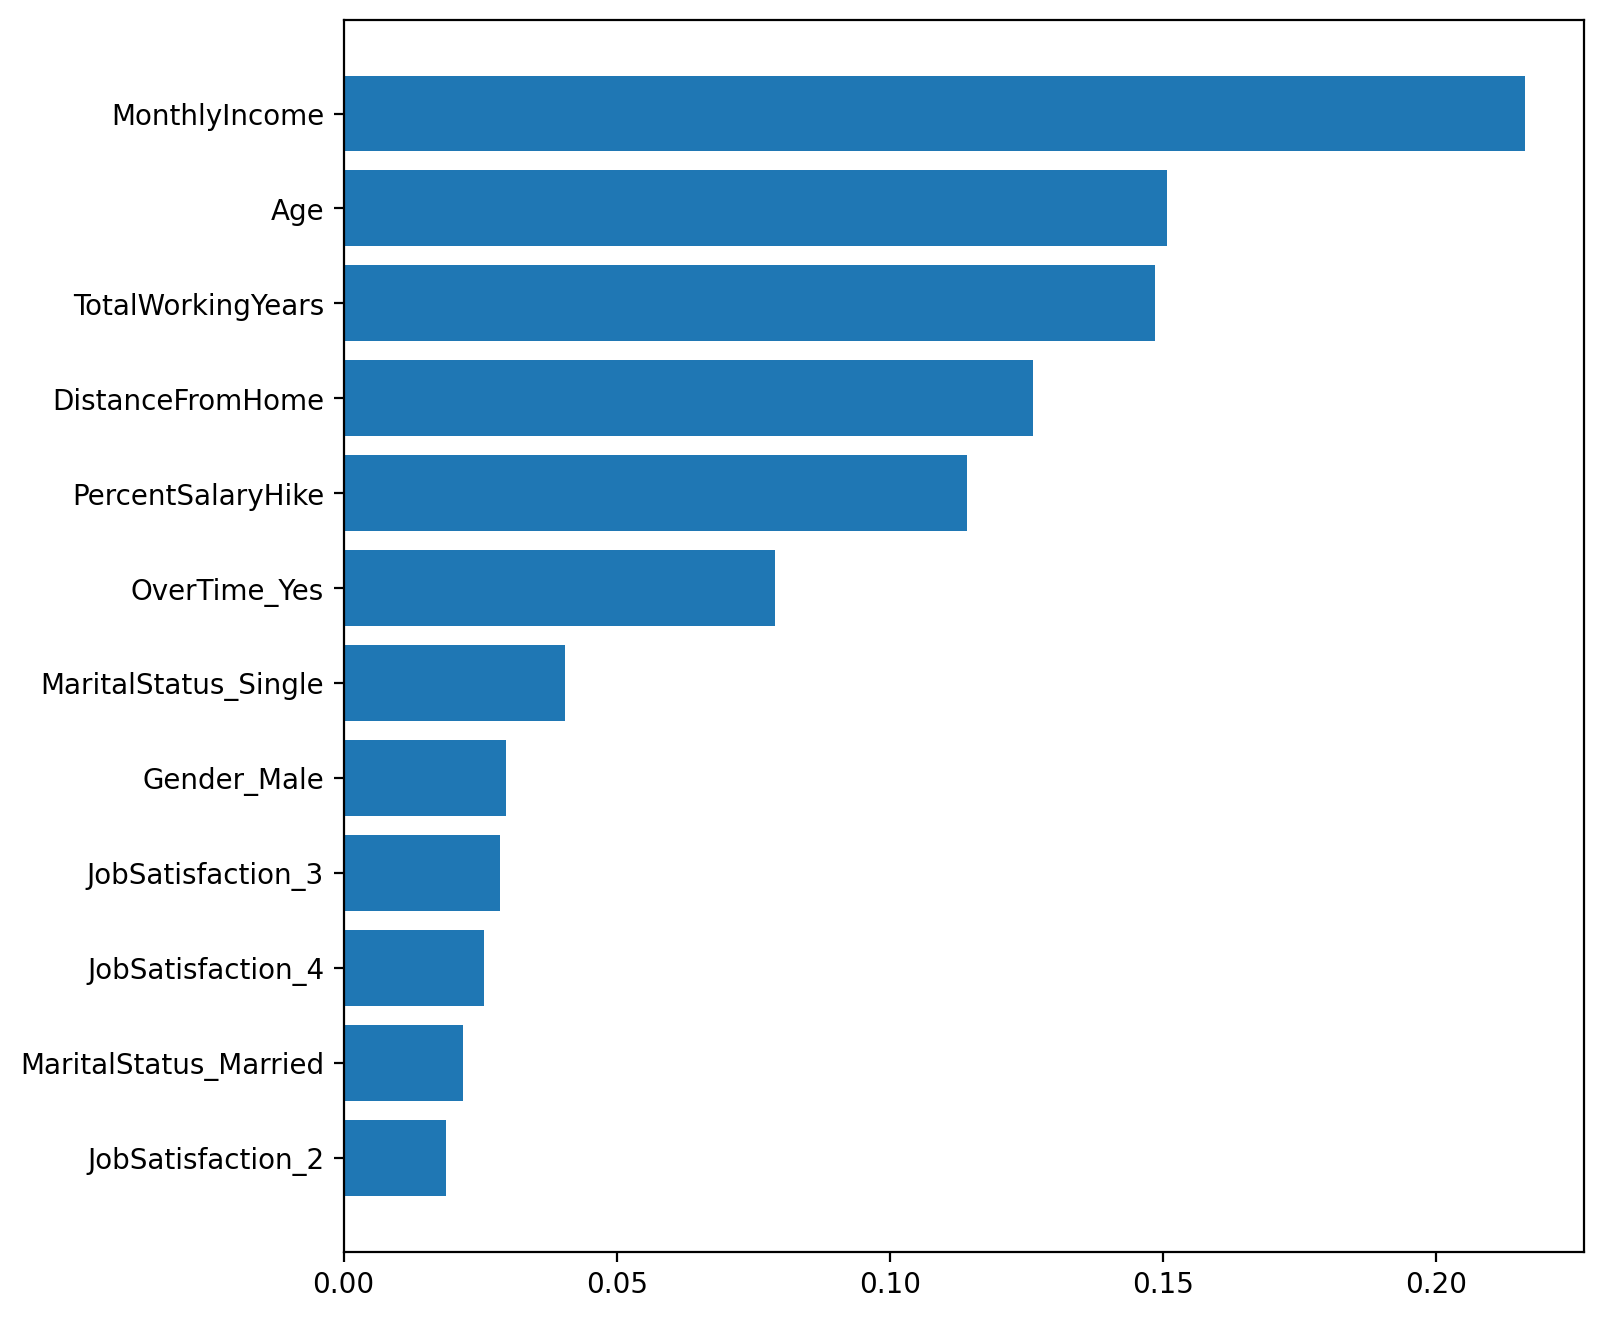

In [98]:
# 변수 중요도 데이터 만들기
importances = model.best_estimator_.feature_importances_
feature_names = X.columns  # X가 DataFrame일 때

fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# 중요도 순으로 정렬
fi = fi.sort_values(by='importance', ascending=True)

# 시각화
plt.figure(figsize=(8, 8))
plt.barh(fi['feature'], fi['importance'])
plt.show()


# 7.성능 평가

- 최적 파라미터로 학습된 모델에 대해 최종 성능 평가 진행

In [96]:
# 예측하기
y_pred = model.predict(X_test)

In [97]:
# 평가하기
print('CM :', confusion_matrix(y_test, y_pred))
print('='*70)
print('Class_report :', classification_report(y_test, y_pred))

CM : [[290   8]
 [ 50  11]]
Class_report :               precision    recall  f1-score   support

           0       0.85      0.97      0.91       298
           1       0.58      0.18      0.28        61

    accuracy                           0.84       359
   macro avg       0.72      0.58      0.59       359
weighted avg       0.81      0.84      0.80       359

